# EOS database demo (proof of concept)

## 1. Loading stuff

All the code (database class, routine to load data, routines to filter/manipulate data, and plotting routines) is hidden in the `./modules` folder.

In [1]:
from modules import EOSDatabase
from modules.functions import *

Read all the available thermo data. It will go through all sub-folders to find all files that end with `_thermo.dat`. It will also read the metadata contained in each corresponding `_thermo.toml` file, and it will load that data into the python object. The point is: **developpers add more files, users just need to give the path to the folder**.

Description of EOS stuff is in [Section 5](#section_eos). 

In [2]:
database = EOSDatabase("./data")

All data loaded successfully from ./data.


## 2. Printing stuff

I created a little script to easily print the summary of the database that has been loaded. This script is entirely customisable by developpers. Again: **developpers add features, users access the data easily**.

In [3]:
database.summary_thermo()

EOSDatabase summary thermo
--------------------------
Rows   : 566
Columns: 25
--------------------------
caracas2024 (NaCa2Al3Fe4Mg30Si24O65)
fischer2011 (FeO)
hakim2018 (Fe)
miozzi2020 (Fe)
solomatovacaracas2021 (NaCa2Al3Fe4Mg30Si24O65)


*For developpers*: all the data is just a giant pandas dataframe. If you are more familiar with pandas dataframes, you can just use them instead.

In [4]:
import pandas as pd
dataframe = database.df_thermo
# print the available keys of the dataframe
print(dataframe.keys())
# print just the P-rho-T-citation info
print(dataframe[["P[Pa]","rho[kg/m^3]","T[K]","entry"]])

Index(['rho[kg/m^3]', 'P[Pa]', 'dP[Pa]', 'T[K]', 'dT[K]', 'unique_id',
       'science_material', 'science_formula', 'science_phase',
       'science_method', 'data_delimiter', 'label', 'entry', 'drho[kg/m^3]',
       'V[m^3/mol]', 'dV[m^3/mol]', 'c/a', 'dc/a', 'science_cristal',
       'other_notes', 'rho[g/cm^3]', 'MDsteps', 'P[GPa]', 'dP[GPa]',
       'U[J/mol]'],
      dtype='object')
            P[Pa]  rho[kg/m^3]     T[K]                           entry
0    3.620000e+10       4040.0  1994.22  solomatovacaracas2021_pyrolite
1    1.942000e+10       3530.0  1995.31  solomatovacaracas2021_pyrolite
2    8.720000e+09       3110.0  1994.66  solomatovacaracas2021_pyrolite
3    3.110000e+09       2750.0  1995.34  solomatovacaracas2021_pyrolite
4   -4.200000e+08       2440.0  1999.77  solomatovacaracas2021_pyrolite
..            ...          ...      ...                             ...
561  1.216308e+14     105886.6   300.00                 hakim2018_hcpfe
562  1.252043e+14     107178.0  

## 3. Manipulating the database

Here are a few "methods" (python routines) that I vibe-wrote to manipulate the database object. For example, one method prints all the species that exist in the table (material, formula, source).

In [5]:
database.print_species_thermo()

Species in thermo database
--------------------------

iron
  - Fe : hakim2018
  - Fe : miozzi2020

pyrolite
  - NaCa2Al3Fe4Mg30Si24O65 : caracas2024
  - NaCa2Al3Fe4Mg30Si24O65 : solomatovacaracas2021

wustite
  - FeO : fischer2011


Supposedly we will have 500 different entries (500 papers) for 50 different materials, we only want to keep some of it. We have methods to isolate specific information. Here, I coded a script that filters the database in order to keep only things that contain "iron" in the column "material". In the future, we (developpers) will add more user-friendly filters.

Note: filtering by `field="formula"` and `contains="Fe"` works, but since pyrolite has iron, it will be kept too.

In [6]:
db_iron = database.filter(
    field="science_material",
    contains="iron",
)

db_iron.print_species_thermo()

Species in thermo database
--------------------------

iron
  - Fe : hakim2018
  - Fe : miozzi2020


## 4. Outputs: plots and writing to file

Probably one of the most important features of this catalog: be able to write all the data into a file. Again, I went ahead and defined a script making it very easy to do.

In [7]:
db_iron.export_tsv(filename="thermo_iron")


Export complete
File: output/thermo_iron_20260715.tsv
Rows exported: 312


And I also went a bit crazy and defined a method to do an easy plot: plot all the rho-P-T data, using unique combinations of point styles to distinguish sources.

Found 7 entries


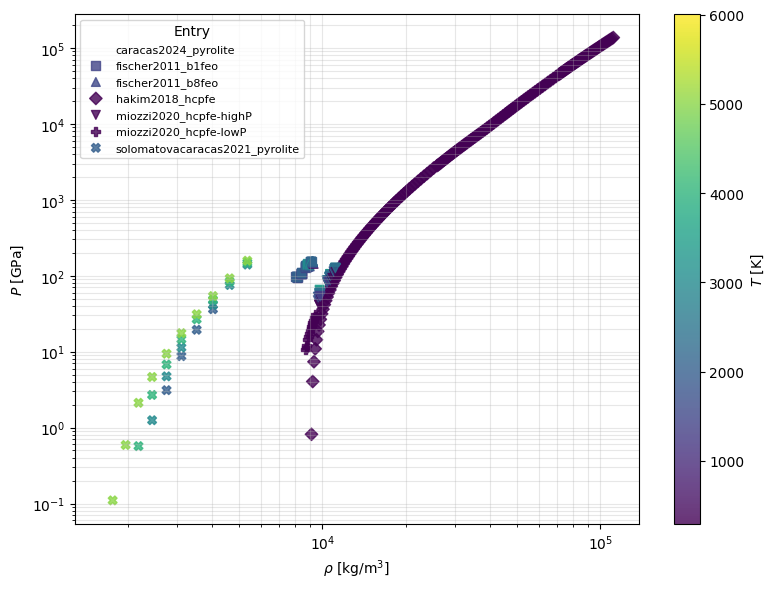

In [8]:
database.plot_thermo_rhopt()

Which of course also works for any filtered database, like that of iron.

Found 3 entries


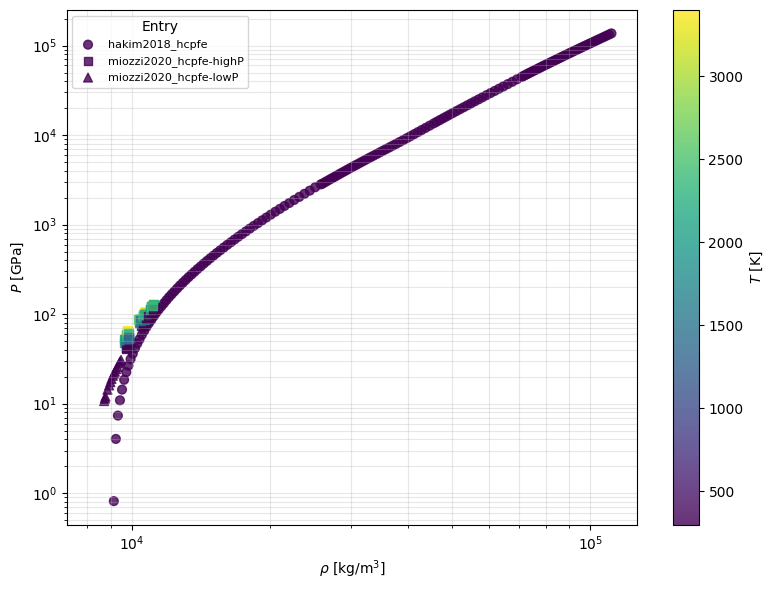

In [9]:
db_iron.plot_thermo_rhopt()

Here I'm just playing around with the plot to make it look nicer. It's really powerful that the entire plot object is just passed to the main program and you can manipulate it however you want...

Found 3 entries


(-50.0, 500.0)

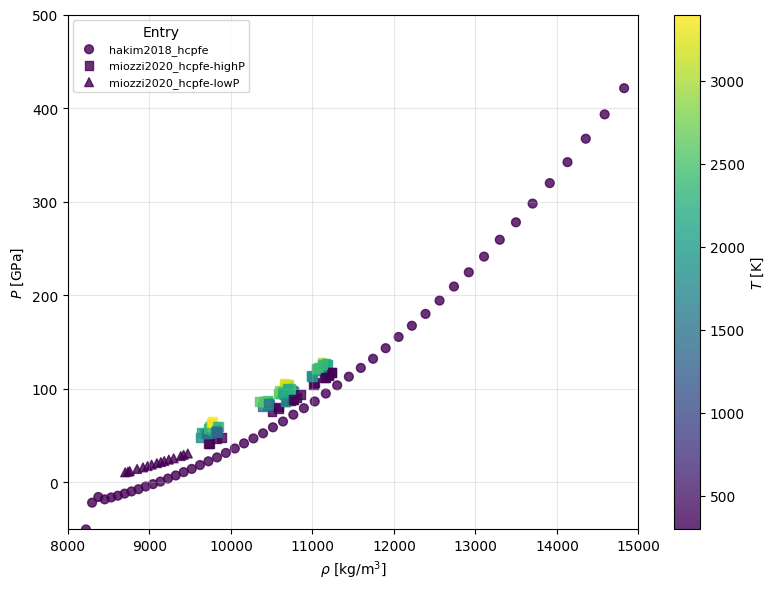

In [10]:
import matplotlib.pyplot as plt
db_iron.plot_thermo_rhopt(plt_show=False)
plt.xscale('linear')
plt.yscale('linear')
plt.xlim(8e3,15e3)
plt.ylim(-50,500)

# 5. Loading EOS and extracting (experimental) <a id='section_eos'></a>

We can applyt the same methodology to EOSs. With the same framework, the EOSs were already loaded earlier.

We can define some methods to print summary of available EOS.

In [11]:
database.summary_eos()

EOSDatabase summary eos
-----------------------
Rows   : 25
Columns: 65
-----------------------
attia2026 (Fe)
attia2026 (H2O)
attia2026 (MgSiO3)
canoamoros2026 (H2O)
dorogokupets2017 (Fe)
fischer2011 (FeO)
hollandpowell2011 (Fe2Si2O6)
hollandpowell2011 (Fe2SiO4)
hollandpowell2011 (Mg2Si2O6)
hollandpowell2011 (Mg2SiO4)
luo2024 (Fe)
luodeng2025 (MgSiO3)
miozzi2020 (Fe)
sakai2016 (MgSiO3)
sokolova2022 (MgSiO3)
wolf2015 ((Mg0.87Fe0.13)SiO3)
wolf2015 (MgSiO3)


In [12]:
database.print_species_eos()

Species in eos database
-----------------------

bridgmanite
  - (Mg0.87Fe0.13)SiO3 : wolf2015
  - MgSiO3 : wolf2015

clinoenstatite
  - MgSiO3 : sokolova2022

enstatite
  - Mg2Si2O6 : hollandpowell2011

fayalite
  - Fe2SiO4 : hollandpowell2011

ferrosilite
  - Fe2Si2O6 : hollandpowell2011

forsterite
  - Mg2SiO4 : hollandpowell2011

iron
  - Fe : attia2026
  - Fe : dorogokupets2017
  - Fe : luo2024
  - Fe : miozzi2020

magnesium silicate
  - MgSiO3 : attia2026
  - MgSiO3 : luodeng2025

orthoenstatite
  - MgSiO3 : sokolova2022

post-perovskite
  - MgSiO3 : sakai2016

water
  - H2O : attia2026
  - H2O : canoamoros2026

wustite
  - FeO : fischer2011


If we want to work with just one EOS of interest, it's a good idea to extract it from the full catalog. First, search for available entries, then get that entry.

In [13]:
print(database.df_eos["entry"])

0             luodeng2025_liquidmgsio3
1                    fischer2011_b1feo
2                    fischer2011_b8feo
3                   canoamoros2026_H2O
4                     miozzi2020_hcpfe
5         hollandpowell2011_forsterite
6        hollandpowell2011_ferrosilite
7           hollandpowell2011_fayalite
8       hollandpowell2011_fayalite-liq
9          hollandpowell2011_enstatite
10    hollandpowell2011_forsterite-liq
11                        attia2026_Fe
12                       attia2026_H2O
13                    attia2026_MgSiO3
14                    luo2024_liquidfe
15              dorogokupets2017_bccfe
16              dorogokupets2017_hcpfe
17           dorogokupets2017_liquidfe
18              dorogokupets2017_fccfe
19         sokolova2022_orthoenstatite
20       sokolova2022_hpclinoenstatite
21       sokolova2022_lpclinoenstatite
22            wolf2015_bridgmanite13fe
23                wolf2015_bridgmanite
24            sakai2016_postperovskite
Name: entry, dtype: objec

In [14]:
miozzi_eos = database.get_eos(entry="miozzi2020_hcpfe")

And then use the existing functions to get information from that EOS.

In [15]:
print_science(miozzi_eos)


Science of entry:  miozzi2020_hcpfe
-------
material: iron
formula: Fe
phase: solid
method: DAC
cristal: hcp


In [16]:
print_description(miozzi_eos)


Description of entry:  miozzi2020_hcpfe
-----------
type: fit
cold_type: bm3
thermal_exist: True
thermal_type: debye
reference_temperature: 300.0


In [17]:
print_validity(miozzi_eos)


Validity of entry:  miozzi2020_hcpfe
--------
min_p: 10000000000.0
max_p: 150000000000.0
min_t: 300.0
max_t: 4000.0
min_rho: 8000.0
max_rho: 12000.0


In [18]:
print_parameters(miozzi_eos)

Parameters of entry:  miozzi2020_hcpfe
----------
V_0: 22.8
K_0: 129.0
K_0_prime: 6.2
gamma_0: 1.5
rho_0: 8.7
dK_0: 6.0
dK_0_prime: 2.0
T_0: 300.0
q_debye: 0.8
dV_0: 2.0
drho_0: 0.8
